# 08 -- Custom Styling and Multi-Format Export

This notebook covers advanced output control: how to override Venn colours
and labels, manipulate the resulting SVG with `lxml`, style UpSet bars in
custom palettes, export diagrams to SVG / PNG / PDF at any resolution, and
wire up the force-directed network graph with custom node colours and edge
metrics.

**What you will learn:**

- Override default set names, fill colours, and diagram title at render time
- Parse and patch SVG elements with `lxml` (brand-colour tweaks, extra
  decorations, accessibility attributes)
- Apply per-bar custom colours to the UpSet intersection chart
- Export to `.svg`, `.png` (72 dpi / 300 dpi), and `.pdf`; compare file sizes
- Customise the network graph: node colours, edge metric, and layout seed
- Understand where PowerPoint embedding fits (roadmap pointer)


In [1]:
import venn_diagram_lab as vdl

print(f'venn-diagram-lab {vdl.__version__}')

venn-diagram-lab 2.2.3


In [2]:
result = vdl.analyze(
    vdl.load_sample('dataset_real_cancer_drivers_4'),
    model='auto',
)

# Quick sanity check
n_sets = len(result.dataset.set_names)
n_items = sum(len(v) for v in result.dataset.items.values())
print(f'Sets       : {list(result.dataset.set_names)}')
print(f'Universe   : {n_items} items (with overlaps)')
print(f'Model      : {result.model}')

Sets       : ['Vogelstein', 'COSMIC_CGC', 'OncoKB', 'IntOGen']
Universe   : 2583 items (with overlaps)
Model      : venn-4-set


## Custom set names and colors

Every render function accepts optional keyword arguments to override the
defaults that come from the loaded dataset:

| kwarg | Type | Effect |
|-------|------|--------|
| `set_names` | `dict[str, str]` | Map letter (`'A'`) to display label |
| `colors` | `dict[str, str]` | Map letter to CSS hex colour |
| `title` | `str` | Diagram heading shown in the SVG |

Unspecified letters keep the dataset defaults. This is useful when a figure
must match corporate or journal colour palettes.


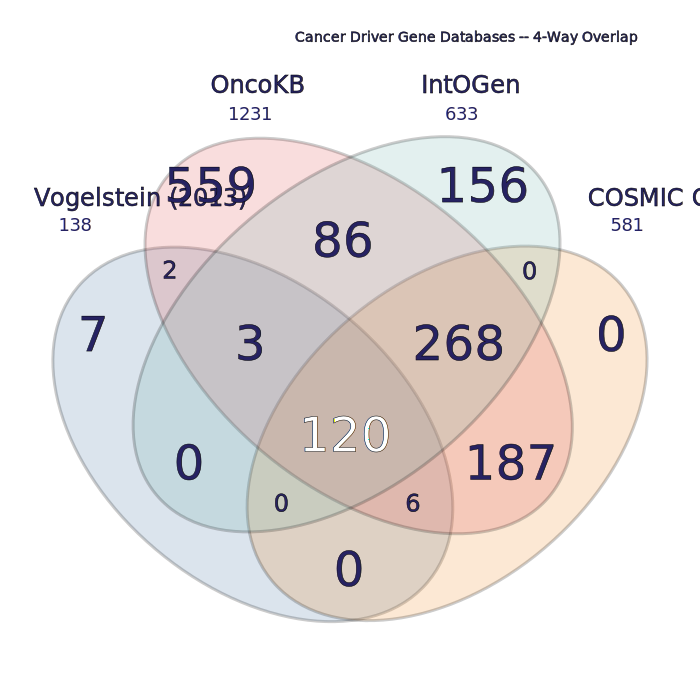

In [3]:
img = result.render_venn(
    set_names={
        'A': 'Vogelstein (2013)',
        'B': 'COSMIC CGC',
        'C': 'OncoKB',
        'D': 'IntOGen',
    },
    colors={
        'A': '#4E79A7',
        'B': '#F28E2B',
        'C': '#E15759',
        'D': '#76B7B2',
    },
    title='Cancer Driver Gene Databases -- 4-Way Overlap',
)
img  # displays inline in Jupyter

## Post-render SVG manipulation with lxml

The `SvgImage.svg` attribute holds the raw SVG string. Because it is plain
XML, you can parse it with `lxml`, walk the element tree, and modify any
attribute before serialising back to a string or saving to disk.

Typical use-cases:

- Swap a fill colour for an on-brand hex that differs from the palette
- Increase stroke width for high-DPI print
- Add `aria-label` attributes for accessibility
- Inject a `<title>` or `<desc>` element for screen readers
- Embed a logo `<image>` element


In [4]:
from lxml import etree

# Parse the SVG string into an element tree
root = etree.fromstring(img.svg.encode())

# Find ShapeA and override its fill to a darker brand colour
for el in root.iter():
    if el.attrib.get('id') == 'ShapeA':
        original_style = el.attrib.get('style', '')
        # Replace only the fill: portion so stroke and opacity are preserved
        el.attrib['style'] = original_style.replace(
            'fill:#4E79A7', 'fill:#1B4F72'
        )
        print('Original style:', original_style)
        print('Modified style:', el.attrib['style'])
        break

Original style: opacity:0.2;fill:#4E79A7;stroke:#000000;stroke-width:3;stroke-miterlimit:10;
Modified style: opacity:0.2;fill:#1B4F72;stroke:#000000;stroke-width:3;stroke-miterlimit:10;


In [5]:
modified_svg = etree.tostring(root, encoding='unicode')

# Confirm the edit is present in the serialised string
print(modified_svg[:500])

<svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" version="1.1" x="0px" y="0px" style="enable-background:new 0 0 700 700;" xml:space="preserve" viewBox="0 0 700 700">
<g id="Shapes">
	<ellipse id="ShapeA" style="opacity:0.2;fill:#1B4F72;stroke:#000000;stroke-width:3;stroke-miterlimit:10;" transform="matrix(-0.6461 0.7633 -0.7633 -0.6461 747.7516 521.9661)" cx="252.9" cy="434.3" rx="150.5" ry="228.9"/>
	<ellipse id="ShapeB" style="opacity:0.2;fill:#F28E2B;stroke:#


In [6]:
# Save the hand-patched SVG to disk
from pathlib import Path

patched_path = Path('/tmp/cancer_drivers_patched.svg')
patched_path.write_text(modified_svg, encoding='utf-8')
print(f'Patched SVG saved: {patched_path} ({patched_path.stat().st_size} bytes)')

Patched SVG saved: /tmp/cancer_drivers_patched.svg (6288 bytes)


## Custom UpSet bar colors

The UpSet chart supports three `color_mode` values:

| mode | behaviour |
|------|-----------|
| `'depth'` | colour by intersection degree (default) |
| `'heatmap'` | colour by intersection size on a Reds scale |
| `'custom'` | colour by label via the `colors` mapping |

In `'custom'` mode, the `colors` dict maps the intersection label
(e.g. `'A'`, `'AB'`, `'ACD'`) to a CSS hex string. Unlabelled
intersections fall back to a neutral grey.


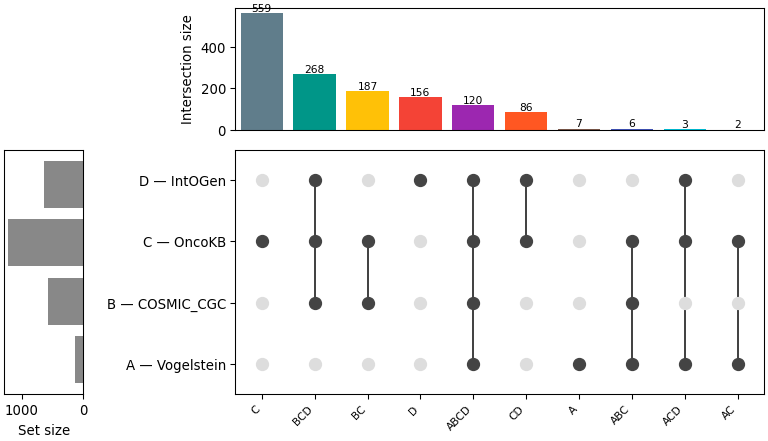

In [7]:
upset_fig = result.render_upset(
    color_mode='custom',
    colors={
        'ABCD': '#9C27B0',  # All four -- purple
        'ABC':  '#3F51B5',  # Three-way without IntOGen
        'ABD':  '#2196F3',
        'ACD':  '#00BCD4',
        'BCD':  '#009688',
        'AB':   '#4CAF50',
        'AC':   '#8BC34A',
        'AD':   '#CDDC39',
        'BC':   '#FFC107',
        'BD':   '#FF9800',
        'CD':   '#FF5722',
        'A':    '#795548',
        'B':    '#9E9E9E',
        'C':    '#607D8B',
        'D':    '#F44336',
    },
)
upset_fig  # displays inline in Jupyter

## Multi-format export

### Format and DPI trade-offs

| Format | Use-case | Notes |
|--------|----------|-------|
| `.svg` | Web, slides, further editing | Vector; infinitely scalable; smallest file |
| `.png` @ 72 dpi | Screen / presentation preview | Fast; compact; not print-ready |
| `.png` @ 300 dpi | Journal figures, posters | ~4x larger than 72 dpi; sharp at print size |
| `.pdf` | Publication submission, LaTeX `\includegraphics` | Vector; universally accepted |

The `save()` method accepts a `dpi` keyword (ignored for SVG).
The DPI scale is applied as a multiplier on the native SVG canvas size
(baseline 96 dpi), so `dpi=300` produces an image roughly 3x wider and
taller in pixels than `dpi=96`.


In [8]:
from pathlib import Path

out_dir = Path('/tmp/exports')
out_dir.mkdir(exist_ok=True)

# Render once, save four ways
venn_img = result.render_venn(
    title='Cancer Driver Gene Databases',
    colors={'A': '#4E79A7', 'B': '#F28E2B', 'C': '#E15759', 'D': '#76B7B2'},
)

venn_img.save(out_dir / 'diagram.svg')
venn_img.save(out_dir / 'diagram_screen.png', dpi=72)
venn_img.save(out_dir / 'diagram_print.png', dpi=300)
venn_img.save(out_dir / 'diagram.pdf')

print(f'{'File':<25}  {'Bytes':>10}  {'KB':>8}')
print('-' * 48)
for f in sorted(out_dir.iterdir()):
    sz = f.stat().st_size
    print(f'{f.name:<25}  {sz:>10,}  {sz/1024:>7.1f}')

File                            Bytes        KB
------------------------------------------------
diagram.pdf                    48,479     47.3
diagram.svg                     6,264      6.1
diagram_print.png             536,193    523.6
diagram_screen.png             89,574     87.5


### When to use each format

**SVG** is the best choice for most downstream workflows: it can be opened
in Inkscape or Illustrator for final polish, embedded in HTML without
re-encoding, and scaled to any size without quality loss.

**PNG @ 72 dpi** is convenient for quick previews in slide decks or wikis
where file size matters more than sharpness.

**PNG @ 300 dpi** meets the minimum requirement of most journals (Nature,
Cell, PLOS) for raster figure submissions. For a 700 x 700 px SVG canvas,
300 dpi yields a ~2188 x 2188 px PNG.

**PDF** is preferred for LaTeX (`\\includegraphics{diagram.pdf}`) and
for journal-submission portals that accept vector figures, because it
embeds fonts and curves exactly. File size is close to SVG.


## PowerPoint embedding (future work)

For PowerPoint reports, install `python-pptx`:

    !pip install python-pptx

Then embed the diagram as a PNG image on a slide:

```python
# NOTE: code shown for reference only -- python-pptx is NOT installed in
# this notebook. Run it in an environment where python-pptx is available.
#
# from pptx import Presentation
# from pptx.util import Inches
#
# prs = Presentation()
# slide = prs.slides.add_slide(prs.slide_layouts[5])  # blank layout
#
# # Export Venn at 300 dpi first
# venn_img.save('/tmp/diagram_print.png', dpi=300)
#
# # Add picture to slide (left=0.5in, top=1in, width=5in)
# slide.shapes.add_picture(
#     '/tmp/diagram_print.png',
#     left=Inches(0.5), top=Inches(1.0), width=Inches(5.0),
# )
# prs.save('cancer_drivers_report.pptx')
```

Native EMF/WMF embedding (true vector in PowerPoint) requires an SVG-to-EMF
converter such as `librsvg` + `unoconv`. This is tracked as a future
enhancement in the project roadmap.


## Network plot custom node colors

The `render_network()` function accepts a `node_color_map` dict mapping
set letters to hex colours. Node size is proportional to the set's
cardinality (total item count). Edge thickness and colour reflect the
chosen edge metric and statistical significance.


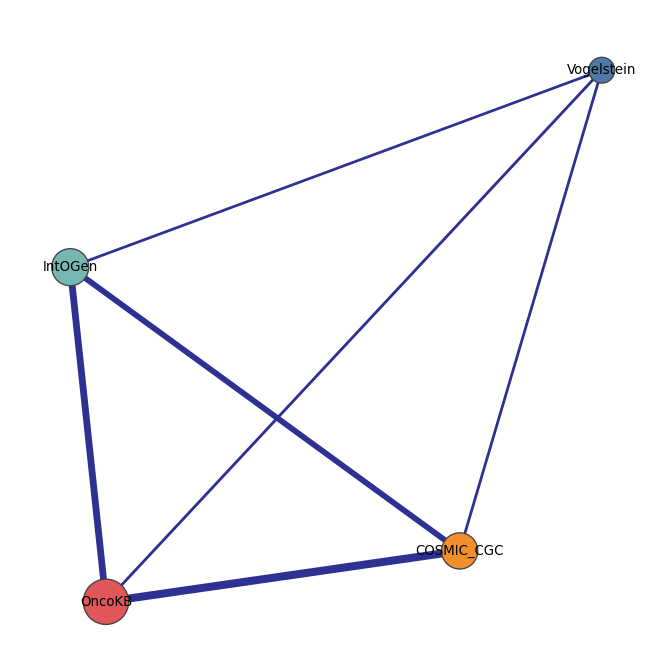

In [9]:
net_custom = result.render_network(
    node_color_map={
        'A': '#4E79A7',  # Vogelstein -- steel blue
        'B': '#F28E2B',  # COSMIC CGC -- amber
        'C': '#E15759',  # OncoKB -- coral
        'D': '#76B7B2',  # IntOGen -- teal
    },
)
net_custom  # displays inline in Jupyter

## Edge metric override

By default, edge weight is the raw intersection count (`'intersection'`).
Switch to `'jaccard'` for a normalised similarity coefficient that is
independent of set size -- more informative when sets vary greatly in
cardinality. Available metrics:

| metric | range | meaning |
|--------|-------|---------|
| `'intersection'` | 0 .. N | Raw shared item count |
| `'jaccard'` | 0 .. 1 | Jaccard similarity (|A & B| / |A | B|) |


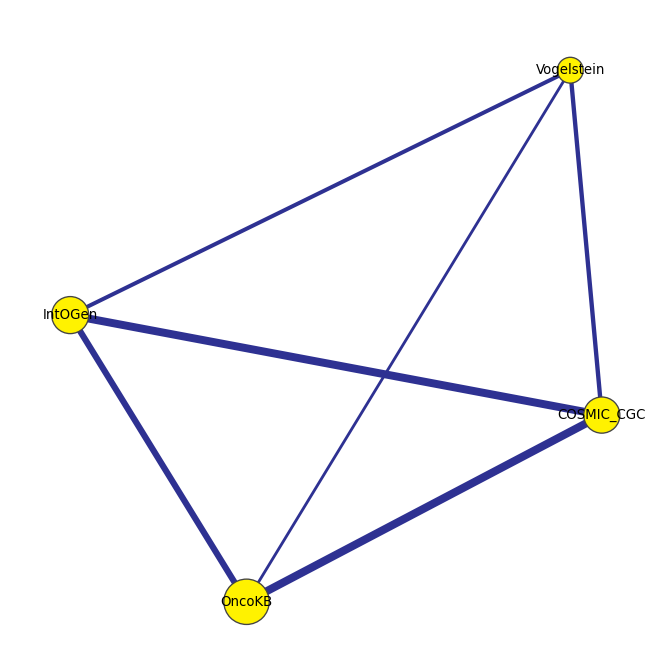

In [10]:
net_jaccard = result.render_network(edge_metric='jaccard')
net_jaccard  # displays inline in Jupyter

## Reproducible layouts via seed

The force-directed layout (Fruchterman-Reingold) is seeded for
determinism. The default seed is `42`. Changing the seed shifts the
node positions while preserving all edge weights and colours -- useful
when the default layout places a label on top of an edge.

Both calls below use `edge_metric='jaccard'` so only the layout differs.


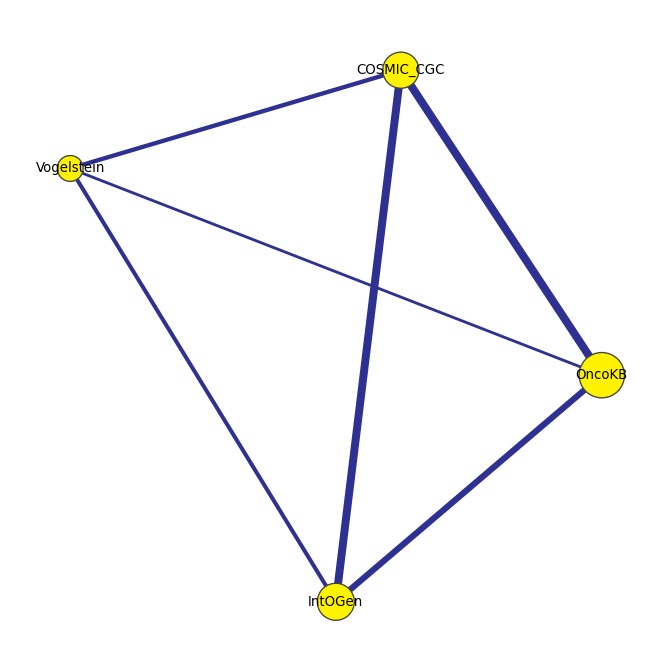

In [11]:
net_seed7 = result.render_network(edge_metric='jaccard', seed=7)
net_seed7  # displays inline in Jupyter

## Cluster heatmap as a matplotlib panel

`render_cluster_heatmap_mpl(result, ax=None, linkage='average')`
returns an `MplImage` with scipy-driven dendrograms + a colorbar
in a standalone figure, OR draws the heatmap into a supplied Axes
(dendrograms suppressed -- caller controls layout). Useful for
embedding into a multi-panel figure or for applying a custom
matplotlib style.


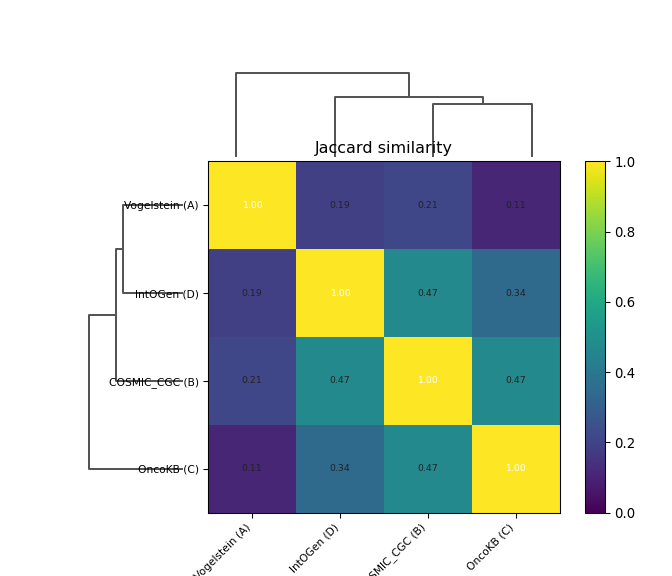

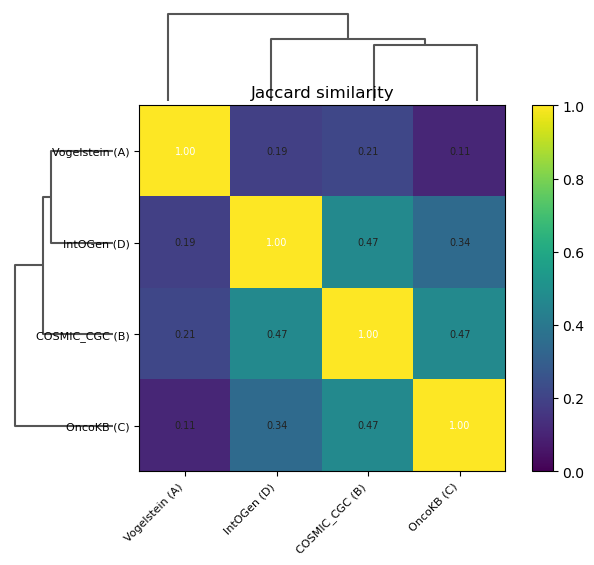

In [12]:
from venn_diagram_lab import render_cluster_heatmap_mpl

# Standalone figure with side dendrograms + colorbar:
img = render_cluster_heatmap_mpl(result, linkage='average', cmap='viridis')
img


## Wrap-up -- all 8 notebooks

You have reached the end of the `venn-diagram-lab` example series.
Here is a quick reference to all notebooks:

| # | Notebook | Focus |
|---|----------|-------|
| 1 | [`01_quickstart.ipynb`](01_quickstart.ipynb) | Install, load sample data, first Venn |
| 2 | [`02_real_cancer_drivers.ipynb`](02_real_cancer_drivers.ipynb) | End-to-end walkthrough with biological data |
| 3 | [`03_proportional_diagrams.ipynb`](03_proportional_diagrams.ipynb) | Area-proportional Venn for 2-3 sets |
| 4 | [`04_upset_vs_venn_vs_network.ipynb`](04_upset_vs_venn_vs_network.ipynb) | Compare three view types side by side |
| 5 | [`05_statistics_deep_dive.ipynb`](05_statistics_deep_dive.ipynb) | Jaccard, Dice, hypergeometric, BH-FDR |
| 6 | [`06_pipeline_integration.ipynb`](06_pipeline_integration.ipynb) | CLI, Snakemake, Nextflow |
| 7 | [`07_pdf_reports.ipynb`](07_pdf_reports.ipynb) | One-call multi-page PDF reports |
| 8 | [`08_custom_styling_and_export.ipynb`](08_custom_styling_and_export.ipynb) | **This notebook** -- lxml, palettes, multi-format export |

For the full API reference run `help(vdl)` or consult the project README.
